## 1. Calculation of test parameters, assessment of the correctness of its implementation and analysis of the experimental results.

### Importing required libraries and methods

In [1]:
# Importing tools for calculating test power and effect
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

#  Import function to round up
from math import ceil

# Main libraries
import pandas as pd
import numpy as np

# Tools for statistical analysis and testing
import scipy.stats as st
import statsmodels.api as sm

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Customizing the display of graphs and tables
%matplotlib inline
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

### 1. Working with historical data (EDA)

#### 1.1. Downloading historical data

In [2]:
sessions_history = pd.read_csv('sessions_project_history.csv')

sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Learning with data

In [3]:
#  Number of unique sessions

user_session_counts = sessions_history.groupby('user_id')['session_id'].nunique()

In [4]:
#  user ID with max number of sessions

top_user_id = user_session_counts.idxmax()
print(f"The user with the most sessions: {top_user_id}")
print(f"Total sessions for this user: {user_session_counts.max()}\n")

The user with the most sessions: 10E0DEFC1ABDBBE0
Total sessions for this user: 10



In [5]:
# all rows from the sessions_history table for this user, sorted by session start date and time

top_user_sessions = sessions_history[sessions_history['user_id'] == top_user_id].sort_values(by='session_start_ts')
top_user_sessions

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Analysis of the number of registrations

In [6]:
# Calculate the total number of unique users (DAU)

total_users_daily = sessions_history.groupby('session_date')['user_id'].nunique().reset_index(name='total_users')

In [7]:
# Count the number of unique registered users

registered_users_daily = (
    sessions_history[sessions_history['registration_flag'] == True]
    .groupby('session_date')['user_id'].nunique()
    .reset_index(name='registered_users'))

In [8]:
# Combine metrics into one table

daily_metrics = pd.merge(total_users_daily, registered_users_daily, on='session_date', how='left').fillna(0)

In [9]:
# Calculate the share of registered users from the total number

daily_metrics['registration_share'] = daily_metrics['registered_users'] / daily_metrics['total_users']

In [10]:
# Sort by date for correct graph construction

daily_metrics = daily_metrics.sort_values(by='session_date')

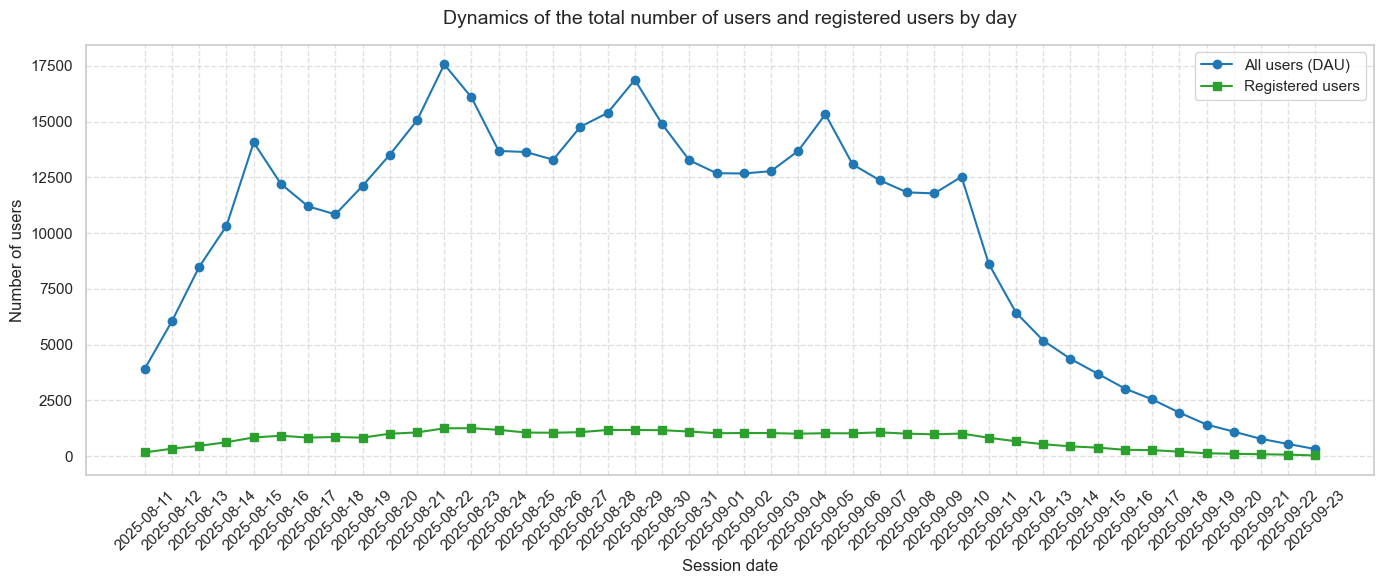

In [11]:
# Line chart: Total number of users and registered users

plt.figure(figsize=(14, 6))
plt.plot(daily_metrics['session_date'], daily_metrics['total_users'], label='All users (DAU)', color='tab:blue', marker='o')
plt.plot(daily_metrics['session_date'], daily_metrics['registered_users'], label='Registered users', color='tab:green', marker='s')

plt.title('Dynamics of the total number of users and registered users by day', fontsize=14, pad=15)
plt.xlabel('Session date', fontsize=12)
plt.ylabel('Number of users', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

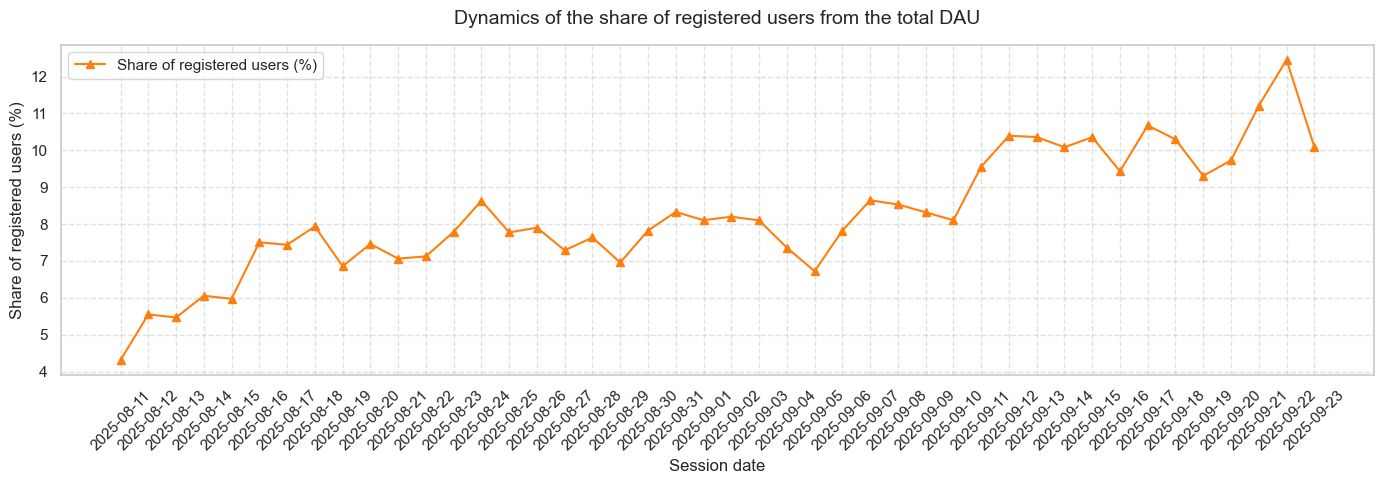

In [12]:
# Line chart: Share of registered users

plt.figure(figsize=(14, 5))
plt.plot(daily_metrics['session_date'], daily_metrics['registration_share'] * 100, label='Share of registered users (%)', color='tab:orange', marker='^')

plt.title('Dynamics of the share of registered users from the total DAU', fontsize=14, pad=15)
plt.xlabel('Session date', fontsize=12)
plt.ylabel('Share of registered users (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

<div style="border: 2px solid dark blue; padding: 20px;">  
    
<span style="color:darkblue; font-size:18px;"> **Interim conclusions:**</span>

* **Cyclicity:** Until early September, traffic had a weekly seasonal pattern, with DAU peaks on Thursdays (August 14, 21, 28, and September 4), followed by a conversion of new users into registrations (August 15, 23, 30, and September 6). Starting on September 10, the overall DAU began to drop critically to almost zero, while the number of registrations remained stable.
* **Metric distortion:** The abnormal jump in the share of registered users before the peak on September 21 (~12.4%) was caused not by an increase in registrations, but by a complete loss of unregistered "guests" from the app.
* **Possible causes and risks:** The situation resembles a traffic purchase disablement or a technical bug in the code for new users. Conducting an A/B test on such a deformed audience is impossible; it is first necessary to restore a stable flow of users.
   
</div> 

#### 1.4. Analysis of the number of pages viewed

In [13]:
# Selection of first user sessions

first_sessions = sessions_history[sessions_history['session_number'] == 1]

In [14]:
# Count the number of sessions for each value of pages viewed

page_counts_dist = first_sessions['page_counter'].value_counts().reset_index()
page_counts_dist.columns = ['page_counter', 'session_count']

# Sort by number of pages
page_counts_dist = page_counts_dist.sort_values(by='page_counter')

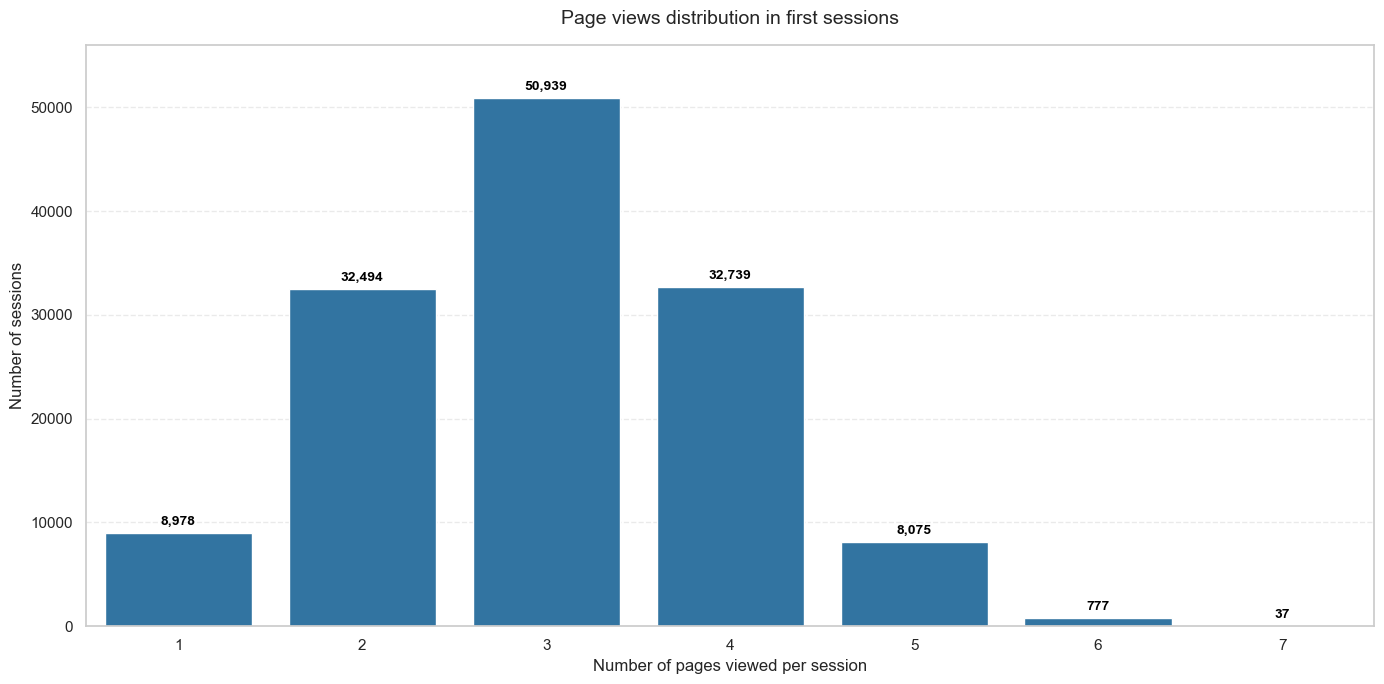

In [15]:
# Diagram

plt.figure(figsize=(14, 7))
ax = sns.barplot(x='page_counter', y='session_count', data=page_counts_dist, color='tab:blue')

# Text column labels
for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=10, fontweight='bold', color='black')
        
plt.title('Page views distribution in first sessions', fontsize=14, pad=15)
plt.xlabel('Number of pages viewed per session', fontsize=12)
plt.ylabel('Number of sessions', fontsize=12)

plt.ylim(0, page_counts_dist['session_count'].max() * 1.1)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

<div style="border: 2px solid dark blue; padding: 20px;">  
    
<span style="color:darkblue; font-size:18px;"> **Interim conclusions:**</span>  
    
* The majority of first sessions—50,939—last exactly 3 page views.
* Approximately 116,000 sessions (the vast majority) fall within the 2 to 4 page range (32,494, 50,939, and 32,739 sessions, respectively).
* Only 8,978 users exit the app on the very first page, indicating a strong performance of the initial screen compared to the overall average.
* Beyond the 4th page, engagement drops fourfold (down to 8,075 sessions at 5 pages) and practically vanishes by pages 6 and 7 (777 and 37 sessions).
   
</div> 

#### 1.5. Percentage of users who viewed more than four pages

In [16]:
# Create column good_session: 1 if pages >= 4, otherwise 0

sessions_history['good_session'] = (sessions_history['page_counter'] >= 4)

In [17]:
# Select only the first user sessions

first_sessions_history = sessions_history[sessions_history['session_number'] == 1]

In [18]:
# Group by days and calculate the average value (the proportion of units in good_session)
# Sort by date 

daily_good_sessions = (
    first_sessions_history
    .groupby('session_date')['good_session']
    .mean()
    .reset_index(name='good_session_share')
    .sort_values(by='session_date'))

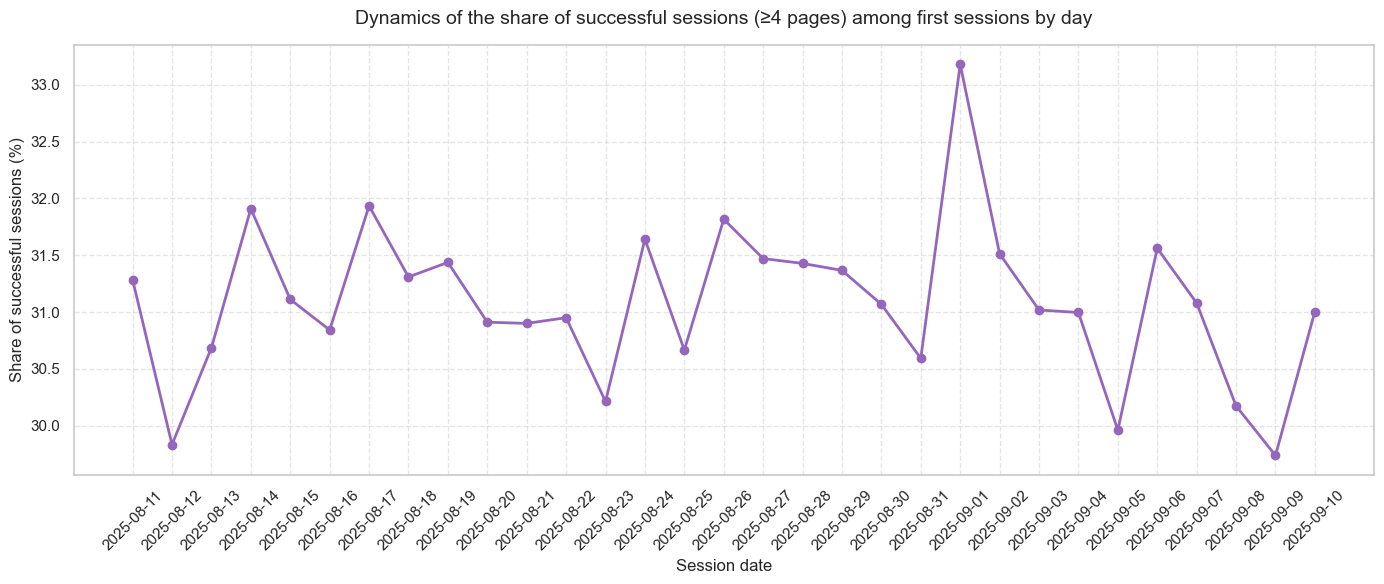

In [19]:
# Line chart

plt.figure(figsize=(14, 6))
plt.plot(daily_good_sessions['session_date'], daily_good_sessions['good_session_share'] * 100, 
         color='tab:purple', marker='o', linewidth=2)

plt.title('Dynamics of the share of successful sessions (≥4 pages) among first sessions by day', fontsize=14, pad=15)
plt.xlabel('Session date', fontsize=12)
plt.ylabel('Share of successful sessions (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<div style="border: 2px solid dark blue; padding: 20px;">  

<span style="color:darkblue; font-size:18px;"> **Interim conclusions:**</span>  
    
* **Baseline:** The share of successful sessions stays within the 30% to 32% range, averaging around 31%.
* **Main peak:** The absolute maximum was recorded on August 31, reaching approximately 33.2%.
* **Lows:** The sharpest drop in engagement occurred on September 8, falling to around 29.7%.
* **A/B test readiness:** The high stability of this metric makes it well-suited for A/B testing. The baseline of 31% will serve as the starting point that the new ML algorithm is expected to outperform.
   
</div> 

### 2. Preparing for the test

#### 2.1. Sample size calculation

In [20]:
# Parameters
alpha = 0.05  # Significance level
beta = 0.2  # Type II error rate (1 - power)
power = 0.8  # Statistical power
p = 0.3  # Baseline proportion (conversion rate)
mde = 0.03  # Minimum Detectable Effect (MDE)

effect_size = proportion_effectsize(p, p * (1 + mde))

# Initialize the NormalIndPower class
power_analysis = NormalIndPower()

# Sample size calculation
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1
)

In [21]:
# Round the resulting value up to the nearest whole number.
required_users_per_group = ceil(sample_size)

print(f"Required sample size for ONE group: {required_users_per_group} пользователей")
print(f"Total users for two groups (А and B): {required_users_per_group * 2}")

Required sample size for ONE group: 41041 пользователей
Total users for two groups (А and B): 82082


<div style="border: 2px solid dark red; padding: 20px;">  
    
<span style="color:darkblue; font-size:18px;"> **Interim conclusions:**</span>  
    
The resulting sample size is 41,041 users per group (or 82,082 users in total).  
This sample size is sufficient to detect a 3% change in the share of successful sessions from the baseline (p = 0.3) with the specified statistical power and significance.
   
</div> 

#### 2.2. Calculating the duration of an A/B test

In [22]:
# Number of unique users for each day in history

daily_users = sessions_history.groupby('session_date')['user_id'].nunique()

In [23]:
# Average number of app users per day based on historical data
avg_daily_users = int(daily_users.mean())

# Calculate the test duration in days as the ratio of the sample size to the average number of users
total_required_users = required_users_per_group * 2  # 7524
test_duration = ceil(total_required_users / avg_daily_users)

print(f"The calculated duration of the A/B test at the current traffic level of {avg_daily_users} users per day will be {test_duration} days")

The calculated duration of the A/B test at the current traffic level of 9907 users per day will be 9 days


### 3. A/B test monitoring

#### 3.1. Checking user distribution

The formula used to calculate the percentage difference is:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [24]:
# Data from the first day of the A/B test

sessions_test_part = pd.read_csv('sessions_project_test_part.csv')

In [25]:
# Number of unique users in each group

group_sizes = sessions_test_part.groupby('test_group')['user_id'].nunique()
users_A = group_sizes.get('A', 0)
users_B = group_sizes.get('B', 0)

print(f"Number of unique users in group A: {users_A}")
print(f"Number of unique users in group B: {users_B}")

Number of unique users in group A: 1477
Number of unique users in group B: 1466


In [26]:
# Percentage difference according to a given formula

p_difference = 100 * abs(users_A - users_B) / users_A
print(f"Percentage difference in the number of users: {p_difference:.2f}%")

Percentage difference in the number of users: 0.74%


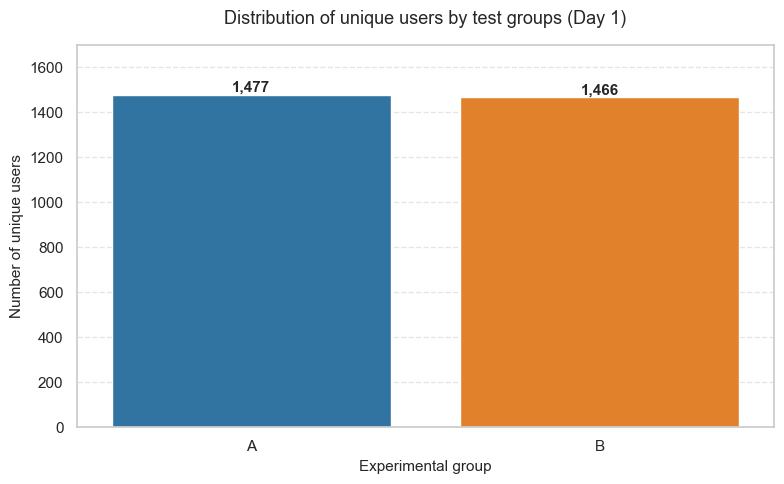

In [27]:
# Visualization of user distribution by groups
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=group_sizes.index, y=group_sizes.values, hue=group_sizes.index, palette=['tab:blue', 'tab:orange'], legend=False)

# Adding signatures
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.title('Distribution of unique users by test groups (Day 1)', fontsize=13, pad=15)
plt.xlabel('Experimental group', fontsize=11)
plt.ylabel('Number of unique users', fontsize=11)
plt.ylim(0, max(users_A, users_B) * 1.15)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<div style="border: 2px solid dark blue; padding: 20px;">  
    
<span style="color:darkblue; font-size:18px;"> **Interim conclusions:**</span>  
    
The difference is less than 1%. This confirms the system is working correctly.  
The groups are initially balanced by size. There is no risk of error.
   
</div> 

#### 3.2. Checking user intersections

In [28]:
# Select sets of unique user_ids for each group

users_in_A = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])
users_in_B = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

In [29]:
# Find the intersection of these sets

intersecting_users = users_in_A.intersection(users_in_B)

print(f"The number of users who fell into both groups at the same time: {len(intersecting_users)}")

The number of users who fell into both groups at the same time: 0


In [30]:
# Additional check as a % of the total base on the first day

overlap_share = 0.0
if len(intersecting_users) > 0:
    total_unique_test = sessions_test_part['user_id'].nunique()
    overlap_share = (len(intersecting_users) / total_unique_test) * 100

print(f"Share of overlapping users: {overlap_share:.2f}%")

Share of overlapping users: 0.00%


#### 3.3. Uniform distribution of users across devices

In [31]:
# Identify unique users and their devices for each group on the first day of the test.

unique_users_devices = sessions_test_part.drop_duplicates(subset=['user_id'])

In [32]:
# Distribution of devices in % within each group

device_dist = (
    unique_users_devices
    .groupby(['test_group', 'device'])['user_id']
    .nunique()
    .groupby(level=0, group_keys=False) 
    .apply(lambda x: 100 * x / float(x.sum()))
    .reset_index(name='share_percent')
)

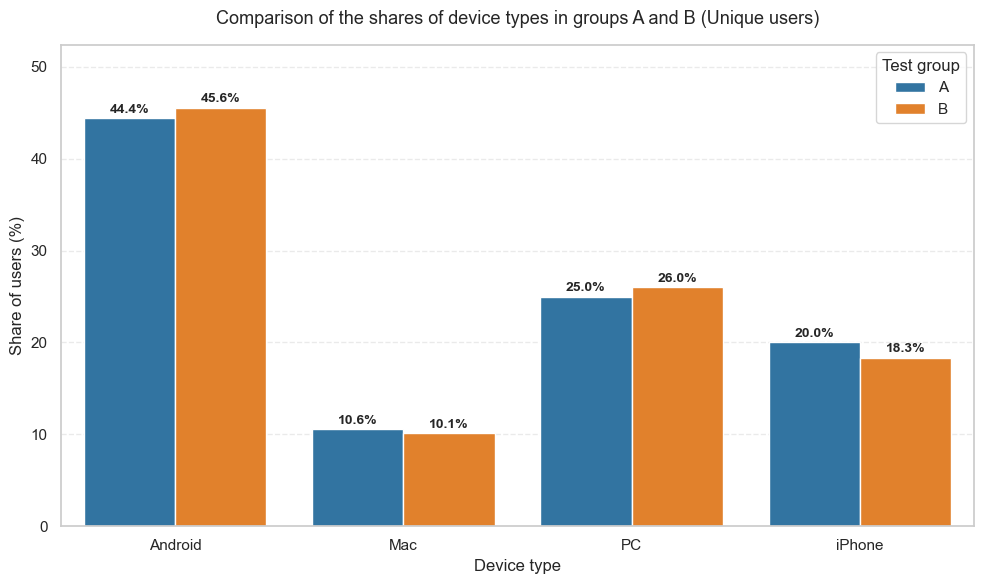

In [33]:
# Grouped bar chart 

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='device', y='share_percent', hue='test_group', data=device_dist, palette=['tab:blue', 'tab:orange'])

# Подписи столбцов
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 6), 
                    textcoords='offset points', 
                    fontsize=10, fontweight='bold')

plt.title('Comparison of the shares of device types in groups A and B (Unique users)', fontsize=13, pad=15)
plt.xlabel('Device type', fontsize=12)
plt.ylabel('Share of users (%)', fontsize=12)
plt.ylim(0, device_dist['share_percent'].max() * 1.15)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Test group', fontsize=11)

plt.tight_layout()
plt.show()

<div style="border: 2px solid dark blue; padding: 20px;">  
    
<span style="color:darkblue; font-size:18px;"> **Interim conclusions:**</span>   
    
* **Platform Leader:** Almost half of the audience in both groups uses Android (~45%).
* **Homogeneity of Shares:** The device structure in groups A and B is virtually identical, with the maximum difference (for iPhone) being a negligible 1.7%.
* **Protection from Factors:** The minimum deviation is within the standard statistical error.
* **Test Purity:** Differences in smartphones or computers will not distort the experiment results. The change in engagement will be a pure effect of the new ML algorithm.
   
</div> 

#### 3.4. Uniform distribution of users across regions

In [34]:
# Identify unique users and their regions for the first day of testing.

unique_users_regions = sessions_test_part.drop_duplicates(subset=['user_id'])

In [35]:
# Distribution of regions in percentages within each group
region_dist = (
    unique_users_regions
    .groupby(['test_group', 'region'])['user_id']
    .nunique()
    .groupby(level=0, group_keys=False) 
    .apply(lambda x: 100 * x / float(x.sum()))
    .reset_index(name='share_percent')
)

# Sorting regions
region_dist = region_dist.sort_values(by='share_percent', ascending=False)

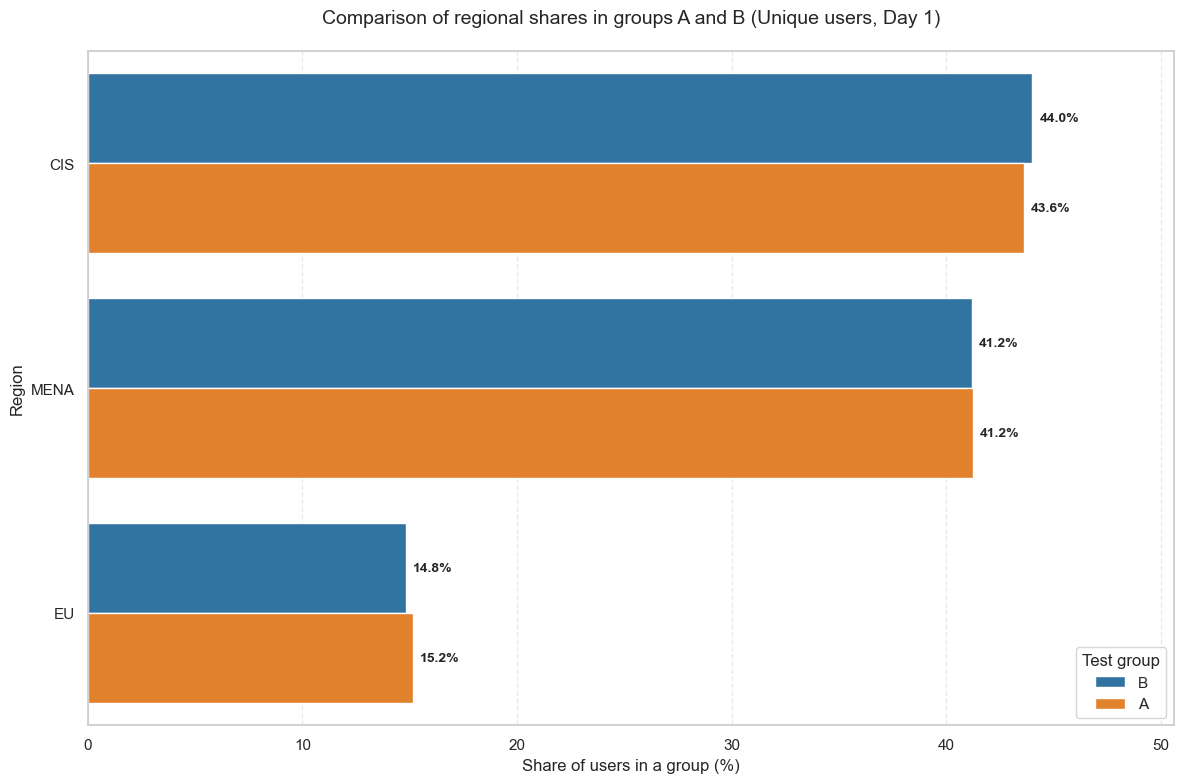

In [36]:
# Horizontal grouped bar plot

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    y='region', 
    x='share_percent', 
    hue='test_group', 
    data=region_dist, 
    palette=['tab:blue', 'tab:orange'],
    orient='h')

# Column labels
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points', 
                    fontsize=10, fontweight='bold')

plt.title('Comparison of regional shares in groups A and B (Unique users, Day 1)', fontsize=14, pad=20)
plt.xlabel('Share of users in a group (%)', fontsize=12)
plt.ylabel('Region', fontsize=12)

# Increase the X-axis limit so that the labels do not extend beyond the graph.
plt.xlim(0, region_dist['share_percent'].max() * 1.15)
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.legend(title='Test group', fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()

<div style="border: 2px solid dark blue; padding: 20px;">  
    
<span style="color:darkblue; font-size:18px;"> **Interim conclusions:**</span>   
    
* **Key markets:** The majority of the audience is concentrated in the CIS (44%) and MENA (41%) regions, with the EU accounting for approximately 15%.  * **Distribution:** Regional shares in groups A and B are virtually identical, and match perfectly within the MENA segment (41.2%). The maximum variance across other regions is a minimal 0.4%.
* **Experiment integrity:** The groups are geographically equivalent. This ensures that regional content differences will not distort the results, and the final change in engagement will be driven solely by the new ML algorithm.
</div> 

#### 3.5. Conclusion after checking the A/B test

<div style="border: 2px solid dark blue; padding: 20px;">  
    
<span style="color:darkblue; font-size:18px;"> **Interim conclusions after A/B test validation:**</span>

The A/B test is running completely correctly, with no violations in the split logic detected.

The randomization system operates without technical glitches (no Sample Ratio Mismatch effect). Experimental groups A and B are initially equivalent in size, device specifications, and geographic representation. This ensures that external factors cannot distort the results, and any observed shifts in metrics are a pure effect of the new ML content recommendation algorithm. The data is ready for final analysis for the entire test period.

</div> 

### 4. Checking the results of an A/B test

#### 4.1. Receiving test results and calculating the main metric

In [37]:
# Data for the entire A/B test period

sessions_test = pd.read_csv('sessions_project_test.csv')

In [38]:
# Create a good_session column: 1 if pages >= 4, otherwise 0

sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

In [39]:
# Display basic information about the dataframe and the first lines for verification

print(f"Total number of sessions for the entire test period: {len(sessions_test)}")
print("\nDistribution of lines by test groups:")
print(sessions_test['test_group'].value_counts())

sessions_test.head()

Total number of sessions for the entire test period: 100005

Distribution of lines by test groups:
test_group
B    50454
A    49551
Name: count, dtype: int64


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2 Formulating the null and alternative hypotheses. Defining the target, proxy, and barrier metrics

<div style="border: 2px solid dark red; padding: 20px;">  
    
<span style="color:darkblue; font-size:18px;"> **Hypothesis Formulation (Adjustments):**</span>

**1. Formulation of Statistical Hypotheses**
* Null Hypothesis (H0): The new ML content ranking algorithm does not affect user engagement, i.e., the proportion of successful sessions in test group B is equal to the proportion of successful sessions in control group A (pB = pA).
* Alternative Hypothesis (H1): The new ML content ranking algorithm changes user engagement, i.e., the proportion of successful sessions in test group B is statistically significantly higher than in control group A (pB > pA).

**2. Metrics**
* Target: Total revenue per user (as customer retention and revenue are linked)
* Proxy metrics: Share of successful sessions, average viewing time per session
* Barrier metrics: Technical barriers, ad churn

</div> 

#### 4.3. Comparison of the percentage of successful sessions

In [40]:
# Selection of the first sessions for the entire period of the A/B test

first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

In [41]:
# The share of successful sessions (good_session_share) for each group

# Сreate a successful session flag: 1, if >= 4 pages were viewed, otherwise 0
first_sessions_test.loc[:, "good_session"] = (
    first_sessions_test["page_counter"] >= 4
).astype(int)

# Aggregating metrics across test groups
group_metrics = first_sessions_test.groupby("test_group")["good_session"].agg(
    ["count", "sum", "mean"]
)
group_metrics.columns = [
    "total_first_sessions",
    "good_sessions_count",
    "good_session_share",
]

# Allocate sample sizes and proportions for each group
n_A = group_metrics.loc["A", "total_first_sessions"]
n_B = group_metrics.loc["B", "total_first_sessions"]

share_A = group_metrics.loc["A", "good_session_share"]
share_B = group_metrics.loc["B", "good_session_share"]

# Display the table
print("Group Metrics")
print(group_metrics)
print("-" * 30)

absolute_diff = (share_B - share_A) * 100

# Выводим текстовые результаты долей и их разницы
print("Results of metrics comparison")
print(f"Percentage of successful first sessions in Group A (Control): {share_A * 100:.2f}%")
print(f"Percentage of successful first sessions in group B (New ML): {share_B * 100:.2f}%")
print(f"Absolute change in metric in the test group: {absolute_diff:+.2f} п.п.")
print("-" * 40)

Group Metrics
            total_first_sessions  good_sessions_count  good_session_share
test_group                                                               
A                          15162                 4787            0.315724
B                          15416                 4851            0.314673
------------------------------
Results of metrics comparison
Percentage of successful first sessions in Group A (Control): 31.57%
Percentage of successful first sessions in group B (New ML): 31.47%
Absolute change in metric in the test group: -0.11 п.п.
----------------------------------------


<div style="border: 2px solid dark blue; padding: 20px;">  
    
<span style="color:darkblue; font-size:18px;"> **Interim conclusions:**</span>   
    
* **Sample size:** A total of 30,578 first sessions were recorded during the test period: 15,162 in Group A and 15,416 in Group B. This significantly exceeds our calculated minimum threshold (7,524 users), guaranteeing high statistical power.
* **Negative dynamics:** The absolute change in the engagement metric in the test group was -0.11 percentage points. The algorithm does not have data on user preferences during the first session, so personalization performed worse than standard top-tier and new apps.

</div> 

#### 4.4. Change in the key metric

In [42]:
# Number of successful sessions in groups A and B

successes_ordered = np.array([4851, 4787])

In [43]:
# Total number of first sessions in groups A and B

trials_ordered = np.array([15416, 15162])

In [44]:
# One-tailed Z-test of proportions

stat, p_value = proportions_ztest(count=successes_ordered, nobs=trials_ordered, alternative='larger')

In [45]:
# Results

print(f"Z-test statistics: {stat:.4f}")
print(f"Resulting p-value: {p_value: .4f}")
print(f"Specified significance level alpha: 0.05")

Z-test statistics: -0.1977
Resulting p-value:  0.5784
Specified significance level alpha: 0.05


<div style="border: 2px solid dark blue; padding: 20px;">  
    
<span style="color:darkblue; font-size:18px;"> **Interim conclusions:**</span>   
    
* **Test Result:** The obtained p-value of 0.578 is critically higher than the established significance level of alpha = 0.05.
* **Solution:** There is no reason to reject the null hypothesis H0. The difference between the proportion of successful sessions in control group A (31.57%) and test group B (31.47%) is purely due to chance and statistically insignificant.

</div> 

#### 4.5. Conclusion from the A/B experiment

<div style="border: 2px solid dark red; padding: 20px;">  
    
<span style="color:darkblue; font-size:18px;"> **Final conclusions:**</span>

**1. Experiment characteristics**
* Period: From October 14 to November 2, 2025 (20 days).
* Sample size: The experiment recorded 30,578 unique user sessions. Group A (Control - old heuristics): 15,162 users. Group B (Test - new ML algorithm): 15,416 users.
* Power: The volume of collected data significantly exceeded the calculated minimum (82,082 users), ensuring high mathematical reliability of the test.

**2. Impact on engagement proxy metrics**
The implementation of the new recommendation algorithm did not result in an increase in the proportion of successful sessions (>=4 pages viewed).
* In Control Group A, the percentage of successful sessions was 31.57%.
* In Test Group B, the percentage of successful sessions was 31.47%.
* The absolute change in the proxy metric was only -0.11 percentage points. The minimal effect (MDE +3.0%) expected by the DS team was not achieved.

**3. Statistical Significance**
The resulting p-value = 0.578 (with a Z-test statistic of -0.1977). Since the p-value is critically higher than the established significance level (alpha = 0.05), there is no reason to reject the null hypothesis.

The observed microdrop of -0.11% is purely random noise. From a mathematical perspective, the new ML algorithm and the old "popular + new" heuristic performed absolutely identically in the first session.

**Results**
Implementing the new recommendation algorithm in its current form for all user sessions is not recommended.
Most likely, the system encountered a problem with missing data at launch. The model is optimized for likes and viewing history. During a new user's first session, this data is not yet available in the system.
Since engagement did not increase at launch, these improvements will not help achieve the main goal—long-term retention and growth of the target metric (total revenue (ARPU)).
</div> 